<a href="https://colab.research.google.com/github/kishor-cypto/projects/blob/main/Skin_Cancer_Detection_Using_an_Artificial_Neural_Network_(ANN)_for_Binary_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.utils import image_dataset_from_directory

In [2]:
cancer_train = "/content/drive/MyDrive/skin cancer binary classification dataset/Skin_Data/Cancer/Training"

cancer_test = "/content/drive/MyDrive/skin cancer binary classification dataset/Skin_Data/Cancer/Testing"

non_train = "/content/drive/MyDrive/skin cancer binary classification dataset/Skin_Data/Non_Cancer/Training"

non_test = "/content/drive/MyDrive/skin cancer binary classification dataset/Skin_Data/Non_Cancer/Testing"

In [3]:
IMG_SIZE = (128,128)

BATCH_SIZE = 32

SEED = 123

In [4]:
train_files = []

train_labels = []

test_files = []

test_labels = []

In [5]:
for img in os.listdir(cancer_train):

    train_files.append(
        os.path.join(
            cancer_train,
            img
        )
    )

    train_labels.append(0)
for img in os.listdir(non_train):

    train_files.append(
        os.path.join(
            non_train,
            img
        )
    )

    train_labels.append(1)
for img in os.listdir(cancer_test):

    test_files.append(
        os.path.join(
            cancer_test,
            img
        )
    )

    test_labels.append(0)
for img in os.listdir(non_test):

    test_files.append(
        os.path.join(
            non_test,
            img
        )
    )

    test_labels.append(1)

In [6]:
train_files = np.array(train_files)

train_labels = np.array(train_labels)

test_files = np.array(test_files)

test_labels = np.array(test_labels)

In [7]:
print()

print("Training Images:")

print(len(train_files))

print()

print("Testing Images:")

print(len(test_files))


Training Images:
84

Testing Images:
204


In [9]:
class_names = [

    "Cancer",

    "Non_Cancer"

]

print(class_names)

['Cancer', 'Non_Cancer']


In [10]:
def load_image(path,label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = image/255.0

    return image,label

In [11]:
train_ds = tf.data.Dataset.from_tensor_slices(

    (

        train_files,

        train_labels

    )

)

train_ds = train_ds.map(

    load_image

)

train_ds = train_ds.shuffle(

    100

)

train_ds = train_ds.batch(

    BATCH_SIZE

)

train_ds = train_ds.prefetch(

    tf.data.AUTOTUNE

)

In [12]:
test_ds = tf.data.Dataset.from_tensor_slices(

    (

        test_files,

        test_labels

    )

)

test_ds = test_ds.map(

    load_image

)

test_ds = test_ds.batch(

    BATCH_SIZE

)

test_ds = test_ds.prefetch(

    tf.data.AUTOTUNE

)

In [13]:
for images,labels in train_ds.take(1):

    print(images.shape)

    print(labels.shape)

(32, 128, 128, 3)
(32,)


In [14]:
model = tf.keras.Sequential([

    tf.keras.layers.Flatten(
        input_shape=(128,128,3)
    ),

    tf.keras.layers.Dense(
        512,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        len(class_names),
        activation="softmax"
    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,166,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,330,818 (96.63 MB)

 Trainable params: 25,330,818 (96.63 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(

    train_ds,

    epochs=20,

    validation_data=test_ds

)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 90s 44s/step - accuracy: 0.4524 - loss: 22.8707 - val_accuracy: 0.2059 - val_loss: 21.6712
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.4524 - loss: 13.6835 - val_accuracy: 0.2059 - val_loss: 7.4287
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 916ms/step - accuracy: 0.4762 - loss: 5.6796 - val_accuracy: 0.7941 - val_loss: 2.1048
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 998ms/step - accuracy: 0.5238 - loss: 5.4174 - val_accuracy: 0.7941 - val_loss: 0.9945
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5476 - loss: 2.5449 - val_accuracy: 0.2059 - val_loss: 3.4441
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.5952 - loss: 1.9472 - val_accuracy: 0.2108 - val_loss: 3.4012
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5476 - loss: 2.1570 - val_accuracy: 0.7941 - val_loss: 1.2124
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4881 - loss: 2.6718 - val_accuracy: 0.7941 - val_loss: 1.0320
Epoch

In [19]:
# =================================
# MODEL EVALUATION
# =================================

loss, accuracy = model.evaluate(test_ds)

print()

print("========== RESULTS ==========")

print()

print("Test Accuracy : {:.2f}%".format(accuracy*100))

print()

print("Test Loss : {:.2f}%".format(loss*100))

print()

print("=============================")

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 199ms/step - accuracy: 0.7941 - loss: 1.1790

========== RESULTS ==========

Test Accuracy : 79.41%

Test Loss : 117.90%



In [20]:
model.save(

    "SkinCancerANN.keras"

)

print(

    "Model Saved"

)

Model Saved


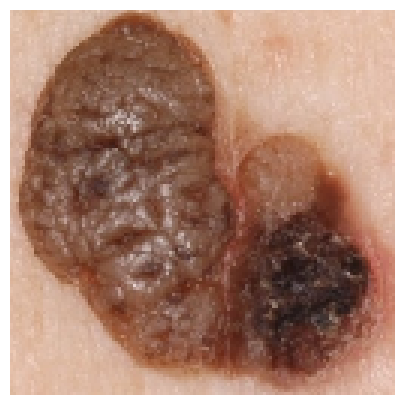



Prediction : Non_Cancer

Confidence : 100.00%



In [22]:
# ==========================================
# SINGLE IMAGE PREDICTION
# ==========================================

img_path = "/content/drive/MyDrive/skin cancer binary classification dataset/Skin_Data/Non_Cancer/Testing/1009-1.JPG"

img = tf.keras.preprocessing.image.load_img(

    img_path,

    target_size=(128,128)

)

plt.figure(figsize=(5,5))

plt.imshow(img)

plt.axis("off")

plt.show()

img_array = tf.keras.preprocessing.image.img_to_array(img)

img_array = img_array/255.0

img_array = np.expand_dims(

    img_array,

    axis=0

)

prediction = model.predict(

    img_array,

    verbose=0

)

predicted_index = np.argmax(

    prediction

)

predicted_class = class_names[

    predicted_index

]

confidence = np.max(

    prediction

)*100

print()

print("========================")

print()

print("Prediction :",predicted_class)

print()

print("Confidence : {:.2f}%".format(confidence))

print()

print("========================")

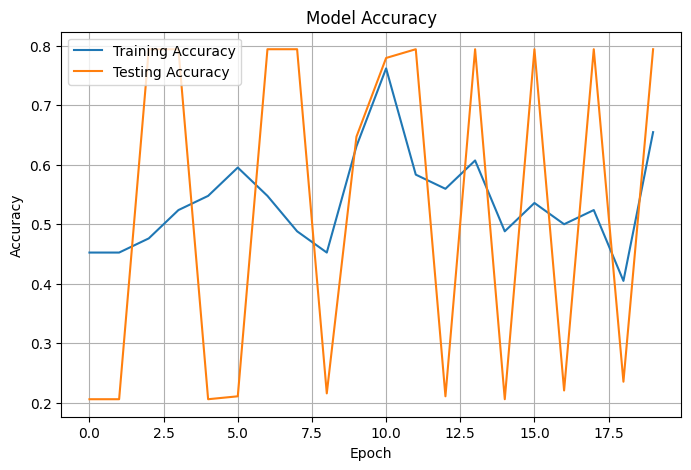

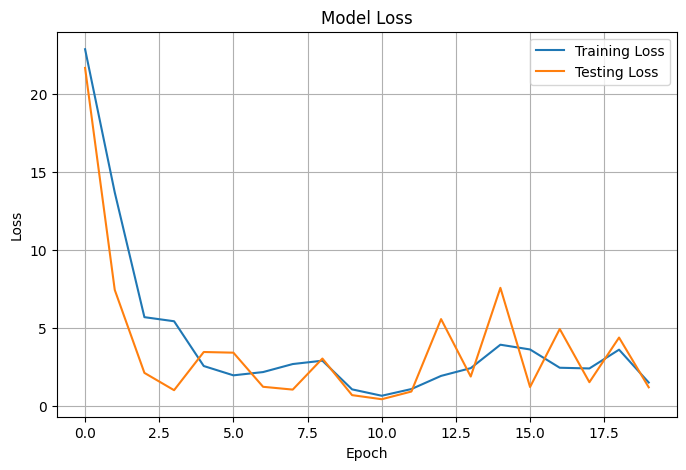

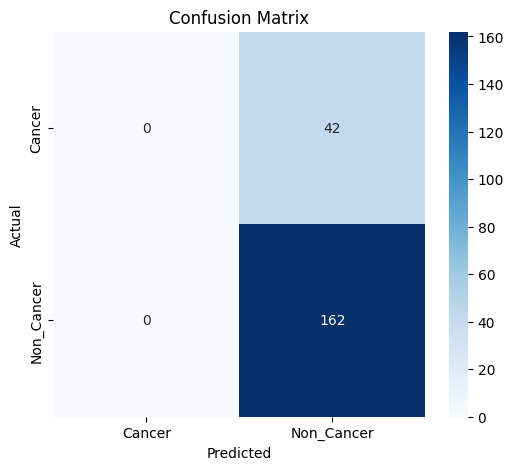


========== Classification Report ==========

              precision    recall  f1-score   support

      Cancer       0.00      0.00      0.00        42
  Non_Cancer       0.79      1.00      0.89       162

    accuracy                           0.79       204
   macro avg       0.40      0.50      0.44       204
weighted avg       0.63      0.79      0.70       204


F1 Score : 70.30%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


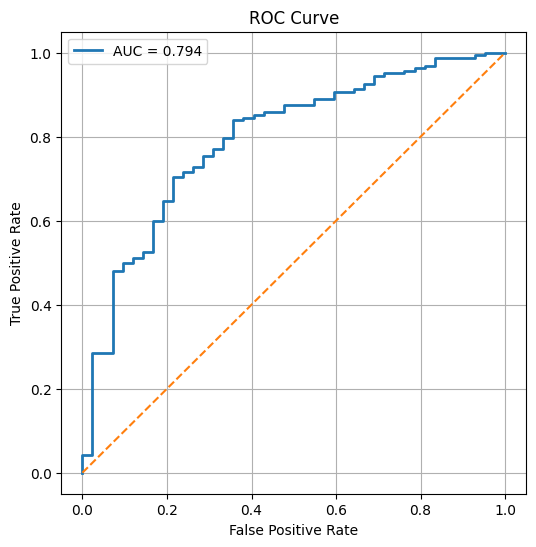


ROC AUC Score : 79.38%

========== FINAL RESULTS ==========

Accuracy : 79.41%

Loss : 117.90%

F1 Score : 70.30%

ROC AUC : 79.38%



In [23]:
# ==========================================
# MODEL EVALUATION AND ALL CURVES
# ==========================================

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

import seaborn as sns

# Accuracy Curve
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Testing Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Loss Curve
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Testing Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Predictions

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_classes)

    y_prob.extend(predictions[:,1])

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# Confusion Matrix

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=class_names,

    yticklabels=class_names

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# Classification Report

print()

print("========== Classification Report ==========\n")

print(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names

    )

)

# F1 Score

f1 = f1_score(

    y_true,

    y_pred,

    average='weighted'

)

print()

print("F1 Score : {:.2f}%".format(f1*100))

# ROC Curve

fpr,tpr,thresholds = roc_curve(

    y_true,

    y_prob

)

roc_auc = auc(

    fpr,

    tpr

)

plt.figure(figsize=(6,6))

plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label="AUC = %0.3f"%roc_auc

)

plt.plot(

    [0,1],

    [0,1],

    linestyle='--'

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

print()

print("ROC AUC Score : {:.2f}%".format(roc_auc*100))

# Final Results

loss,accuracy = model.evaluate(
    test_ds,
    verbose=0
)

print()

print("========== FINAL RESULTS ==========\n")

print("Accuracy : {:.2f}%".format(accuracy*100))

print()

print("Loss : {:.2f}%".format(loss*100))

print()

print("F1 Score : {:.2f}%".format(f1*100))

print()

print("ROC AUC : {:.2f}%".format(roc_auc*100))

print()

print("===================================")